# 🧪 Model Lab: XGBoost (Optimized)

이 노트북은 XGBoost 모델의 하이퍼파라미터를 최적화하고, 주가 방향성 예측 성능을 다각도로 평가합니다.

### 🧪 실험 설정
- **데이터 분할:** Train(70%) / Val(15%) / Test(15%)
- **평가 지표:** Accuracy, Precision, Recall, F1-Score, ROC-AUC
- **최적화 전략:** TimeSeriesSplit 기반 GridSearchCV (정확도 기준)

In [5]:
# 1. 기본 설정
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 7)
sns.set_theme(style="whitegrid")

In [6]:
# 2. 데이터 준비
df = pd.read_csv("../data/processed/selected_features_data.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Date', 'ticker'])

exclude = ['Date', 'ticker', 'target', 'next_return']
features = [c for c in df.columns if c not in exclude]
X = df[features]
y = df['target']

# 70/15/15 시계열 분할
n = len(df)
tr_idx, val_idx = int(n*0.7), int(n*0.85)

X_train, y_train = X.iloc[:tr_idx], y.iloc[:tr_idx]
X_val, y_val = X.iloc[tr_idx:val_idx], y.iloc[tr_idx:val_idx]
X_test, y_test = X.iloc[val_idx:], y.iloc[val_idx:]

print(f"Train set: {X_train.shape}, Val set: {X_val.shape}, Test set: {X_test.shape}")

Train set: (1024, 25), Val set: (220, 25), Test set: (220, 25)


In [7]:
# 3. 모델 학습 및 파라미터 최적화 (개선 버전)
from sklearn.model_selection import PredefinedSplit

# PredefinedSplit 설정 (Val 데이터 기준 최적화)
test_fold = np.concatenate([
    np.full(len(X_train), -1),
    np.full(len(X_val), 0)
])
ps = PredefinedSplit(test_fold)

X_combined = pd.concat([X_train, X_val])
y_combined = pd.concat([y_train, y_val])

# 규제 파라미터(gamma, alpha, lambda) 및 과적합 방지 파라미터 추가
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [0, 0.1, 1]
}

# GridSearchCV 수행 (F1-score 기준)
grid_search = GridSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid=param_grid,
    cv=ps,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("--- 최적 파라미터 검색 중 (Val 기준 & F1 최적화)... ---")
grid_search.fit(X_combined, y_combined)

best_model = grid_search.best_estimator_
print(f"최적 파라미터: {grid_search.best_params_}")
print(f"최적 검증 점수 (F1): {grid_search.best_score_:.4f}")

def get_metrics(model, X_set, y_set, label):
    preds = model.predict(X_set)
    probs = model.predict_proba(X_set)[:, 1]
    return {
        'Set': label,
        'Accuracy': accuracy_score(y_set, preds),
        'Precision': precision_score(y_set, preds),
        'Recall': recall_score(y_set, preds),
        'F1': f1_score(y_set, preds),
        'AUC': roc_auc_score(y_set, probs)
    }

results = pd.DataFrame([
    get_metrics(best_model, X_train, y_train, 'Train'),
    get_metrics(best_model, X_val, y_val, 'Val'),
    get_metrics(best_model, X_test, y_test, 'Test')
])

print("\n--- XGBoost Performance (Optimized) ---")
display(results)

--- 최적 파라미터 검색 중 (Val 기준 & F1 최적화)... ---
Fitting 1 folds for each of 4374 candidates, totalling 4374 fits
최적 파라미터: {'colsample_bytree': 0.9, 'gamma': 0.1, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'reg_alpha': 1, 'reg_lambda': 0, 'subsample': 0.9}
최적 검증 점수 (F1): 0.6644

--- XGBoost Performance (Optimized) ---


,Set,Accuracy,Precision,Recall,F1,AUC
0,Train,0.604492,0.578664,0.974592,0.726166,0.742074
1,Val,0.718182,0.656442,0.946903,0.775362,0.865272
2,Test,0.581818,0.576159,0.756522,0.654135,0.567619


--- 최적 파라미터로 Boosting Round별 Accuracy 추적 중 ---


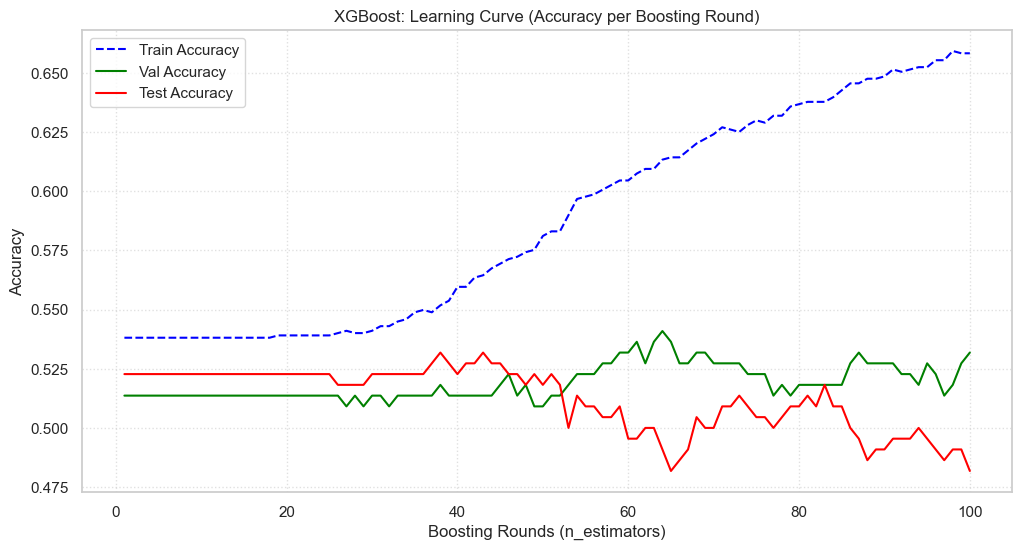

최종 Round 결과 - Train: 0.6582, Val: 0.5318, Test: 0.4818


In [9]:
# 4. Iteration(Boosting Round)별 학습 곡선 분석
# XGBoost 최신 버전(2.0+)에서는 eval_metric을 생성자(init)에서 설정해야 합니다.

best_params = grid_search.best_params_.copy()
# GridSearchCV에서 학습된 모델의 n_estimators 사용
n_estimators = best_params.get('n_estimators', 200)
if 'n_estimators' in best_params:
    del best_params['n_estimators']

# 학습 과정을 추적하기 위해 생성자에서 eval_metric='error' (1-accuracy) 설정
model_iter = XGBClassifier(**best_params, n_estimators=n_estimators, random_state=42, eval_metric='error')

print(f"--- 최적 파라미터로 Boosting Round별 Accuracy 추적 중 ---")

model_iter.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val), (X_test, y_test)],
    verbose=False
)

# eval_results에서 error 값을 가져와 Accuracy로 변환 (1 - error)
results_dict = model_iter.evals_result()
# results_dict 구조: {'validation_0': {'error': [...]}, 'validation_1': ...}
train_accs = [1 - x for x in results_dict['validation_0']['error']]
val_accs = [1 - x for x in results_dict['validation_1']['error']]
test_accs = [1 - x for x in results_dict['validation_2']['error']]

# 학습 곡선 시각화
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(train_accs) + 1), train_accs, label='Train Accuracy', color='blue', linestyle='--')
plt.plot(range(1, len(val_accs) + 1), val_accs, label='Val Accuracy', color='green')
plt.plot(range(1, len(test_accs) + 1), test_accs, label='Test Accuracy', color='red')

plt.title('XGBoost: Learning Curve (Accuracy per Boosting Round)')
plt.xlabel('Boosting Rounds (n_estimators)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print(f"최종 Round 결과 - Train: {train_accs[-1]:.4f}, Val: {val_accs[-1]:.4f}, Test: {test_accs[-1]:.4f}")

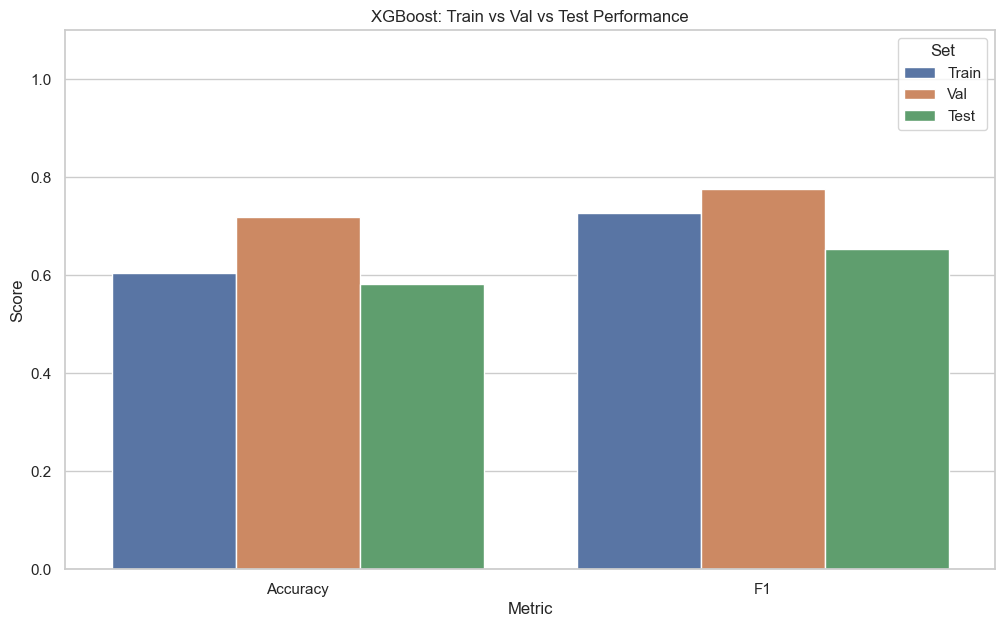

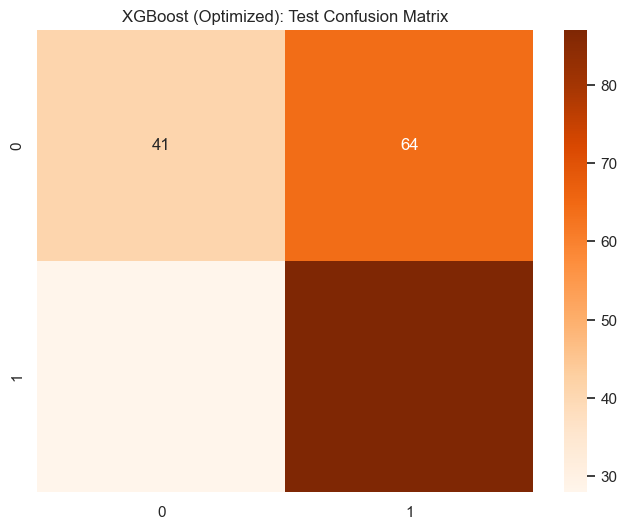

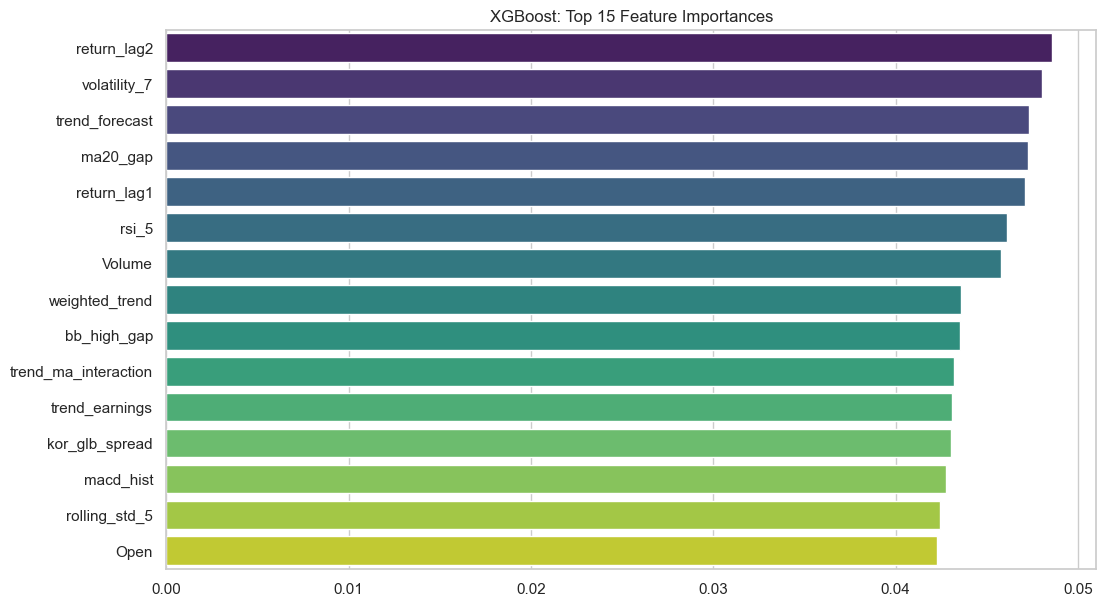

In [10]:
# 4. 결과 시각화

# Accuracy & F1 비교 차트
melted_results = results.melt(id_vars='Set', value_vars=['Accuracy', 'F1'], var_name='Metric', value_name='Score')
sns.barplot(data=melted_results, x='Metric', y='Score', hue='Set')
plt.title("XGBoost: Train vs Val vs Test Performance")
plt.ylim(0, 1.1)
plt.show()

# 혼동 행렬
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title('XGBoost (Optimized): Test Confusion Matrix')
plt.show()

# 변수 중요도
importances = pd.Series(best_model.feature_importances_, index=features).sort_values(ascending=False).head(15)
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title("XGBoost: Top 15 Feature Importances")
plt.show()